## 1. EDA + Предобработка данных, подготовка сэмплов

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
import random
from tqdm.notebook import tqdm

In [15]:
IMAGE_DIR = "../datasets/train/ISIC2018_Task1-2_Training_Input"
MASK_DIR = "../datasets/train/ISIC2018_Task1_Training_GroundTruth"

NUM_SAMPLES = 100
TARGET_SIZE = (256, 256)

OUTPUT_DIR = f"../processed/sample-{NUM_SAMPLES}"
PROCESSED_IMAGES_PATH = f"{OUTPUT_DIR}/images.npy"
PROCESSED_MASKS_PATH = f"{OUTPUT_DIR}/masks.npy"

random.seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [12]:
image_files = sorted(list(Path(IMAGE_DIR).glob("*.jpg")))
mask_files = sorted(list(Path(MASK_DIR).glob("*.png")))

print(f"Найдено изображений: {len(image_files)}")
print(f"Найдено масок: {len(mask_files)}")

Найдено изображений: 2594
Найдено масок: 2594


### Функции предобработки изображений

In [5]:
def load_image(image_path, target_size):
    """Загрузка и ресайз изображения"""
    image = cv2.imread(str(image_path))
    if image is None:
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
    return image_resized

def load_mask(mask_path, target_size):
    """Загрузка и ресайз маски"""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask_resized = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    mask_binary = (mask_resized > 127).astype(np.float32)
    return mask_binary

def normalize_image(image):
    return image.astype(np.float32) / 255.0

### Загрузка тестового сэмпла

In [6]:
indices = random.sample(range(len(image_files)), NUM_SAMPLES)

images = []
masks = []
failed = 0

for idx in tqdm(indices):
    img_path = image_files[idx]
    mask_path = mask_files[idx]

    image = load_image(img_path, TARGET_SIZE)
    mask = load_mask(mask_path, TARGET_SIZE)

    if image is None or mask is None:
        failed += 1
        continue

    image_norm = normalize_image(image)
    
    images.append(image_norm)
    masks.append(mask)

print(f"Успешно загружено: {len(images)} пар")
print(f"Не удалось загрузить: {failed}")

images_array = np.array(images)
masks_array = np.array(masks)

print(f"\nФорма изображений: {images_array.shape}")
print(f"Форма масок: {masks_array.shape}")

  0%|          | 0/100 [00:00<?, ?it/s]

Успешно загружено: 100 пар
Не удалось загрузить: 0

Форма изображений: (100, 256, 256, 3)
Форма масок: (100, 256, 256)


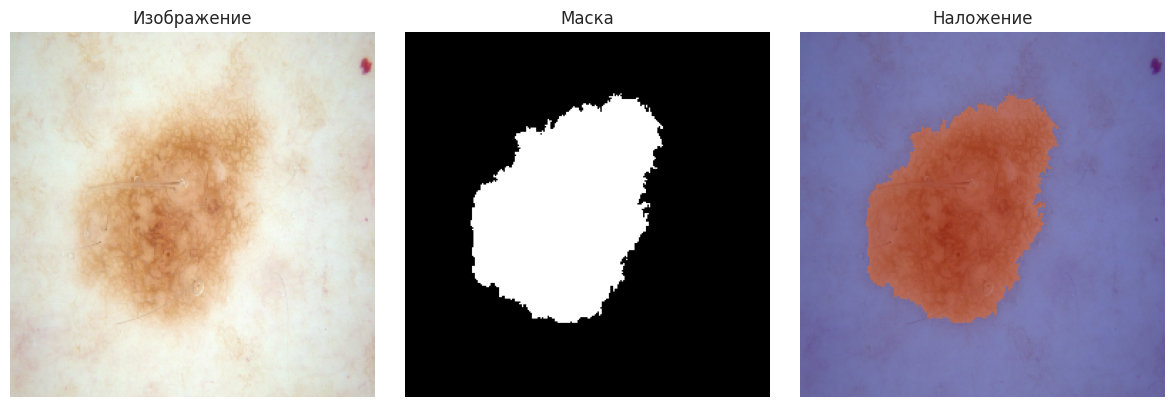

In [17]:
def plot_sample(image, mask):
    """Визуализация примера"""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title("Изображение")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Маска")
    axes[1].axis('off')

    axes[2].imshow(image)
    axes[2].imshow(mask, cmap='jet', alpha=0.5)
    axes[2].set_title("Наложение")
    axes[2].axis('off')
    
    plt.tight_layout()
    return fig

sample_idx = random.choice(range(len(images)))
plot_sample(images[sample_idx], masks[sample_idx])
plt.show()

### Статистика пораженных участков кожи

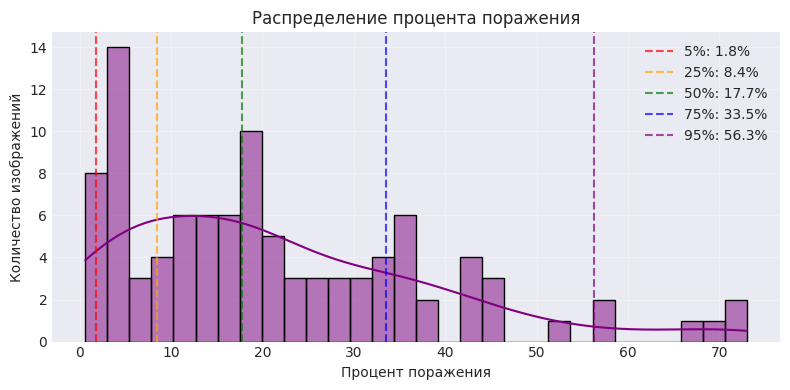

In [19]:
lesion_percentages = []
for mask in masks:
    lesion_pixels = np.sum(mask > 0.5)
    total_pixels = mask.size
    lesion_percentages.append(lesion_pixels / total_pixels * 100)

lesion_percentages = np.array(lesion_percentages)

percentiles = [5, 25, 50, 75, 95]

plt.figure(figsize=(8, 4))
sns.histplot(lesion_percentages, bins=30, kde=True, color='purple')
plt.title('Распределение процента поражения')
plt.xlabel('Процент поражения')
plt.ylabel('Количество изображений')
plt.grid(True, alpha=0.3)

colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']
for p, color in zip(percentiles, colors):
    value = np.percentile(lesion_percentages, p)
    plt.axvline(value, color=color, linestyle='--', alpha=0.7, label=f'{p}%: {value:.1f}%')

plt.legend()
plt.tight_layout()
plt.show()

### Сохранение предобработанных данных

In [9]:
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

np.save(PROCESSED_IMAGES_PATH, images_array)
np.save(PROCESSED_MASKS_PATH, masks_array)

print(f"Данные сохранены:")
print(f"\nРазмер файлов:")
print(f"  Images: {os.path.getsize(PROCESSED_IMAGES_PATH) / (1024**2):.2f} MB")
print(f"  Masks: {os.path.getsize(PROCESSED_MASKS_PATH) / (1024**2):.2f} MB")

Данные сохранены:

Размер файлов:
  Images: 75.00 MB
  Masks: 25.00 MB
